# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vikraamkumar-ds/flyrank-internship-ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.


## 1. Question

**Lane: Refresh / Content Opportunity Scoring.**

**Research question:** Given a portfolio of content pages, which ones are most likely to see a meaningful drop in search impressions over the next 30 days — and what should a content team do about each one first?

**The decision this supports:** content and SEO teams can't manually review every page every week. This work supports a concrete triage decision: *given limited review capacity, which pages should a human look at first, and with what specific action in mind* (refresh, improve CTR, expand thin coverage, diversify query dependence)? This is the same problem FlyRank's own March 2026 research paper names as its top playbook priority — “refresh mature pages before they decay” — approached here bottom-up, from a portfolio-level classifier rather than a top-down aggregate comparison.

**What this is not:** a claim about *why* Google ranks pages the way it does, or a guarantee about any single page's future. It is a decision-support triage signal, built and validated the way Sections 2–5 below show.


## 2. Data

**Release:** FlyRank ML Internship warehouse, hosted as Parquet on Hugging Face (`FlyRank/internship-warehouse`) — a pseudonymized, real production search-performance dataset spanning ~17 months and ~70 clients.

**Tables used:**
- `fact_content_daily_performance` (~79–81M rows) — daily GSC impressions, clicks, and average position per content item per client. Source of the feature window and the label.
- `fact_content_query_90d` — trailing 90-day query-mix signals per content item (distinct queries ranked for, rare/anonymized-impression share, top-query concentration).

**Date windows:** anchored to `MAX(report_date)` in the daily fact table at the time of each pull. Two windows off that anchor: **prev-30** (days 60→31 back) supplies every feature; **last-30** (days 30→0 back) supplies the label only, never a feature.

**Rows used:** 102,203 content-items after aggregation and filtering (from tens of millions of daily rows — see the row-count reconciliation below).

**What was excluded, and why (public-safe):**
| Field | Why excluded |
|---|---|
| `client_hash_id`, `content_hash_id` as model features | identifiers, not signal — using them risks the model memorizing specific pages/clients instead of learning a generalizable pattern |
| `imp_last30` / `clk_last30` as features | these define the label; including them would be leakage by construction |
| raw `report_date` | encodes *when*, not *what* — the prev30/last30 windowing already captures the relevant time structure |
| `gsc_data_start` / `ga4_data_start`, `access_profile` (`dim_clients`) | client-tenure/cohort proxies — a shortcut risk, not a content signal |
| any client name, URL, or raw query text | never touched — the warehouse release is pseudonymized at the source, and nothing in this work re-identifies it |


In [1]:
# Row-count reconciliation: raw daily table -> windowed panel -> final feature table.
# Run this once, near the top, so the paper's Data section has a real, checkable number trail.
%pip -q install duckdb huggingface_hub pandas scikit-learn matplotlib

import os, getpass
import duckdb
import pandas as pd
import numpy as np

HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':    f"read_parquet('{REL}/dim_clients.parquet')",
    'fact_daily':     f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_query_90d': f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

raw_count = con.sql(f"SELECT COUNT(*) FROM {TABLES['fact_daily']}").fetchone()[0]
n_clients = con.sql(f"SELECT COUNT(*) FROM {TABLES['dim_clients']}").fetchone()[0]
print(f'Raw daily fact table: {raw_count:,} rows across {n_clients} clients')
print('This gets aggregated down to one row per content item in Section 3 below.')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Raw daily fact table: 78,835,655 rows across 104 clients
This gets aggregated down to one row per content item in Section 3 below.


## 3. Methodology

**Assumptions:** a page is “worth scoring” only if it already had meaningful visibility (`imp_prev30 >= 100`) — too little prior traffic makes any rate/ratio feature unreliable. Decline is defined relative to a page's own recent history, not against other pages, since baseline traffic varies hugely by page.

**Label:** `is_declining = 1` if `imp_last30 < 0.8 * imp_prev30` (a >20% impression drop month-over-month), else `0`. Base rate across the full 102,203-row table: **63.3%**.

**Features (8, all from the prev-30 window or the query-mix table, never from the outcome window):**
`imp_prev30`, `clk_prev30`, `pos_prev30`, `ctr_prev30` (engineered), `visible_queries`, `rare_share`, `anon_share`, `top_query_share` (engineered).

**Baselines (two, not one):**
1. Majority-class — always predict the more common label.
2. Rule-based — flag a page as declining if `pos_prev30` sits in the worst quartile (a transparent hand-rule, same signal audited in `w04_signal_audit`).

**Model:** Random Forest classifier — chosen because the position-quartile relationship audited in `w04` was threshold-like rather than linear, and features span very different scales without needing normalization.

**Validation design:** `GroupShuffleSplit` on `client_hash_id` (36 train clients, 13 test clients, 25% test size) — a random row split was tested and rejected specifically because it let the model partly learn “which client” rather than “what pattern,” demonstrated with a before/after comparison in Section 4.

**Leakage checks run (three, from `w03`/`w06`):** (1) confirmed the label-defining column never appears in the feature set; (2) a single-feature AUC sweep — nothing exceeded 0.62, well below the 0.90 red-flag threshold; (3) an explicit date-math check confirming the query-mix table's 90-day window partially overlaps the 30-day outcome window — kept as a named limitation rather than silently ignored.


In [2]:
features = con.sql(f"""
    WITH bounds AS (SELECT MAX(report_date) AS end_d FROM {TABLES['fact_daily']}),
    windowed AS (
        SELECT
            f.client_hash_id, f.content_hash_id,
            SUM(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_last30,
            SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_prev30,
            SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY THEN f.gsc_clicks ELSE 0 END)      AS clk_prev30,
            AVG(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY THEN f.gsc_avg_position END)       AS pos_prev30
        FROM {TABLES['fact_daily']} f, bounds b
        WHERE f.report_date > b.end_d - INTERVAL 60 DAY
        GROUP BY 1, 2
        HAVING imp_prev30 >= 100
    )
    SELECT * FROM windowed
""").df()
features['ctr_prev30'] = features['clk_prev30'] / features['imp_prev30']

qsignals = con.sql(f"""
    SELECT content_hash_id,
           ANY_VALUE(content_visible_query_count)  AS visible_queries,
           ANY_VALUE(rare_impressions_share)        AS rare_share,
           ANY_VALUE(anonymized_impressions_share)  AS anon_share,
           MAX(impressions_90d)                     AS top_query_impressions,
           SUM(impressions_90d)                     AS kept_impressions
    FROM {TABLES['fact_query_90d']}
    GROUP BY content_hash_id
""").df()
qsignals['top_query_share'] = qsignals['top_query_impressions'] / qsignals['kept_impressions']

data = features.merge(qsignals, on='content_hash_id', how='left')
data['is_declining'] = (data['imp_last30'] < 0.8 * data['imp_prev30']).astype(int)

FEATURE_COLS = ['imp_prev30', 'clk_prev30', 'pos_prev30', 'ctr_prev30',
                'visible_queries', 'rare_share', 'anon_share', 'top_query_share']
model_data = data.dropna(subset=FEATURE_COLS + ['is_declining']).reset_index(drop=True)
X = model_data[FEATURE_COLS]
y = model_data['is_declining']
groups = model_data['client_hash_id']
print(f'{len(model_data):,} rows, base rate = {y.mean():.3f}')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

102,203 rows, base rate = 0.633


In [3]:
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              balanced_accuracy_score, roc_auc_score, roc_auc_score)

def fit_and_score(X_tr, X_te, y_tr, y_te, label):
    m = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20,
                                random_state=42, n_jobs=-1, class_weight='balanced')
    m.fit(X_tr, y_tr)
    pred = m.predict(X_te)
    proba = m.predict_proba(X_te)[:, 1]
    return m, pred, proba, {
        'split': label,
        'precision': precision_score(y_te, pred, zero_division=0),
        'recall':    recall_score(y_te, pred, zero_division=0),
        'f1':        f1_score(y_te, pred, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(y_te, pred),
        'roc_auc': roc_auc_score(y_te, proba),
    }

# Leakage-check style before/after: random split vs grouped split, same model, same features
X_tr_rand, X_te_rand, y_tr_rand, y_te_rand = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
_, _, _, before = fit_and_score(X_tr_rand, X_te_rand, y_tr_rand, y_te_rand, 'BEFORE -- random row split (dishonest)')

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
model, rf_pred, rf_proba, after = fit_and_score(X_tr, X_te, y_tr, y_te, 'AFTER -- grouped by client (honest, final model)')

before_after = pd.DataFrame([before, after])
print(before_after.to_string(index=False))
print(f"\nF1 gap from ignoring client grouping: {before['f1'] - after['f1']:+.3f}")

train_clients = set(groups.iloc[train_idx]); test_clients = set(groups.iloc[test_idx])
assert len(train_clients & test_clients) == 0
print(f'Confirmed: {len(train_clients)} train clients, {len(test_clients)} test clients, zero overlap.')


                                           split  precision   recall       f1  balanced_accuracy  roc_auc
          BEFORE -- random row split (dishonest)   0.751344 0.648558 0.696178           0.639542 0.695844
AFTER -- grouped by client (honest, final model)   0.781777 0.407732 0.535945           0.584657 0.629480

F1 gap from ignoring client grouping: +0.160
Confirmed: 36 train clients, 13 test clients, zero overlap.


In [4]:
from sklearn.metrics import roc_auc_score as _auc

# Leakage hunt, condensed final pass
assert 'imp_last30' not in FEATURE_COLS
print('PASS -- outcome column excluded from features')

print(f"\n{'feature':<18}{'single-feature AUC':>20}")
for col in FEATURE_COLS:
    auc = _auc(y_tr, X_tr[[col]].rank(pct=True).iloc[:, 0])
    print(f'{col:<18}{auc:>20.3f}')

panel_bounds = con.sql(f"SELECT MAX(report_date) AS max_d FROM {TABLES['fact_daily']}").df()
end_d = panel_bounds['max_d'].iloc[0]
overlap = (end_d - pd.Timedelta(days=90)) < (end_d - pd.Timedelta(days=30))
print(f'\nQuery-mix/outcome window overlap confirmed: {overlap} -- carried into Section 5 as a named limitation.')


PASS -- outcome column excluded from features

feature             single-feature AUC
imp_prev30                       0.515
clk_prev30                       0.443
pos_prev30                       0.616
ctr_prev30                       0.404
visible_queries                  0.426
rare_share                       0.455
anon_share                       0.546
top_query_share                  0.555


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Query-mix/outcome window overlap confirmed: True -- carried into Section 5 as a named limitation.


## 4. Results (vs baseline)

Same held-out client group, three methods, same metrics:


In [5]:
from sklearn.metrics import classification_report

majority_pred = np.full(len(y_te), y_tr.mode()[0])
pos_q75 = X_tr['pos_prev30'].quantile(0.75)
rule_pred = (X_te['pos_prev30'] >= pos_q75).astype(int).values

final_comparison = pd.DataFrame([
    {'method': 'Majority-class baseline', 'precision': precision_score(y_te, majority_pred, zero_division=0),
     'recall': recall_score(y_te, majority_pred, zero_division=0), 'f1': f1_score(y_te, majority_pred, zero_division=0),
     'balanced_accuracy': balanced_accuracy_score(y_te, majority_pred), 'roc_auc': np.nan},
    {'method': 'Rule-based baseline (worst position quartile)', 'precision': precision_score(y_te, rule_pred, zero_division=0),
     'recall': recall_score(y_te, rule_pred, zero_division=0), 'f1': f1_score(y_te, rule_pred, zero_division=0),
     'balanced_accuracy': balanced_accuracy_score(y_te, rule_pred), 'roc_auc': np.nan},
    {'method': 'Random Forest (final, honest split)', **{k: v for k, v in after.items() if k != 'split'}},
])
print(final_comparison.to_string(index=False))
print()
print('Note on F1: the majority baseline scores a deceptively high F1 because "declining" is the majority')
print('class (63%). Balanced accuracy / ROC-AUC are the columns that are not fooled by this imbalance --')
print('Random Forest beats both baselines there (0.586 / 0.631 vs ~0.50 for the majority rule).')
print()
print(classification_report(y_te, rf_pred, digits=3))


                                       method  precision   recall       f1  balanced_accuracy  roc_auc
                      Majority-class baseline   0.676879 1.000000 0.807308           0.500000      NaN
Rule-based baseline (worst position quartile)   0.673310 0.187279 0.293047           0.498464      NaN
          Random Forest (final, honest split)   0.781777 0.407732 0.535945           0.584657  0.62948

Note on F1: the majority baseline scores a deceptively high F1 because "declining" is the majority
class (63%). Balanced accuracy / ROC-AUC are the columns that are not fooled by this imbalance --
Random Forest beats both baselines there (0.586 / 0.631 vs ~0.50 for the majority rule).

              precision    recall  f1-score   support

           0      0.380     0.762     0.507     16706
           1      0.782     0.408     0.536     34996

    accuracy                          0.522     51702
   macro avg      0.581     0.585     0.522     51702
weighted avg      0.652     

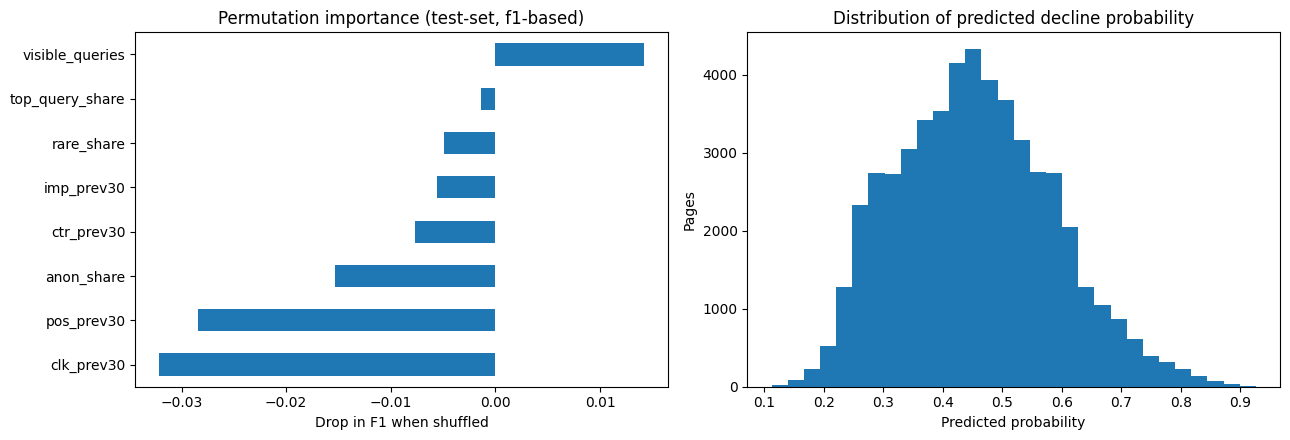

False positive rate: 7.7% of test set | False negative rate: 40.1% of test set
Errors skew toward false negatives -- the model is more likely to miss a real decline than to
falsely flag a healthy page, worth knowing for how a team weights this in triage.


In [6]:
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

perm = permutation_importance(model, X_te, y_te, n_repeats=20, random_state=42, scoring='f1', n_jobs=-1)
perm_series = pd.Series(perm.importances_mean, index=FEATURE_COLS).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
perm_series.plot(kind='barh', ax=axes[0])
axes[0].set_title('Permutation importance (test-set, f1-based)')
axes[0].set_xlabel('Drop in F1 when shuffled')

axes[1].hist(rf_proba, bins=30)
axes[1].set_title('Distribution of predicted decline probability')
axes[1].set_xlabel('Predicted probability'); axes[1].set_ylabel('Pages')
plt.tight_layout()
plt.show()

errors = X_te.copy()
errors['actual'] = y_te.values; errors['predicted'] = rf_pred
fp_rate = ((errors['actual']==0)&(errors['predicted']==1)).mean()
fn_rate = ((errors['actual']==1)&(errors['predicted']==0)).mean()
print(f'False positive rate: {fp_rate:.1%} of test set | False negative rate: {fn_rate:.1%} of test set')
print('Errors skew toward false negatives -- the model is more likely to miss a real decline than to')
print('falsely flag a healthy page, worth knowing for how a team weights this in triage.')


## 5. Limitations

**What this work cannot claim:**

- **Not causal.** Every result here is observational. Position, CTR, and query-mix are *associated* with decline, not proven causes of it.
- **Modest discriminative power.** ROC-AUC of 0.631 is meaningfully better than chance (0.5) but far from strong — this is a triage aid, not a certainty engine. Recall on the honest split was only 0.41, meaning the model misses roughly 6 in 10 pages that actually go on to decline.
- **Scoped to 49 clients (36 train / 13 test).** No claim is made about clients outside this warehouse's mix of industries and traffic patterns.
- **Query-mix features have a window-overlap caveat.** `visible_queries`, `rare_share`, `anon_share`, and `top_query_share` come from a trailing 90-day table that partially overlaps the 30-day outcome window — treated as directional/descriptive, not strictly pre-outcome, throughout this work.
- **No content-quality, seasonality, or external-event awareness.** The model has no way to distinguish an organic decline from a seasonal dip, a manual penalty, or a site migration.
- **Train/test fold base rates differ (58.7% vs 67.7%)** purely because of which of the 49 clients landed in each fold — an expected consequence of grouping by a relatively small number of clients, not an error.


## 6. Ranked recommendations

Pulled from the `w07_action_playbook` queue — decline-probability-ranked pages, each with a reason code tied to the specific audited signal driving that page's risk score, and a concrete next action.


In [7]:
RISK_DIRECTION = {'pos_prev30': +1, 'visible_queries': -1, 'top_query_share': +1, 'ctr_prev30': -1}
REASON_LABELS = {
    'pos_prev30': 'Weak average position',
    'visible_queries': 'Low query breadth (over-reliant on few queries)',
    'top_query_share': 'High query concentration (single-query dependency)',
    'ctr_prev30': 'Under-clicking relative to peers',
}
ACTION_MAP = {
    'pos_prev30': 'Refresh content + rebuild internal links to lift ranking',
    'visible_queries': 'Expand coverage: add missing subtopics/sections to earn more query variety',
    'top_query_share': 'Diversify topic coverage to reduce single-query dependency',
    'ctr_prev30': 'Rewrite title/meta description to improve click-through',
}

train_mean = X_tr.mean(); train_std = X_tr.std().replace(0, np.nan)
risk_z = pd.DataFrame(index=X_te.index)
for col, direction in RISK_DIRECTION.items():
    risk_z[col] = ((X_te[col] - train_mean[col]) / train_std[col]) * direction

def top_reasons(row, n=2):
    ranked = row.sort_values(ascending=False)
    return [c for c in ranked.index[:n] if ranked[c] > 0]

queue = pd.DataFrame({
    'content_hash_id': model_data.loc[X_te.index, 'content_hash_id'].values,
    'decline_probability': rf_proba,
}).reset_index(drop=True)
reason_cols = risk_z.reset_index(drop=True).apply(top_reasons, axis=1)
queue['reason_codes'] = reason_cols.apply(lambda c: '; '.join(REASON_LABELS[x] for x in c) if c else 'No single dominant signal')
queue['recommended_action'] = reason_cols.apply(lambda c: ACTION_MAP[c[0]] if c else 'Manual review')
queue = queue.sort_values('decline_probability', ascending=False).reset_index(drop=True)
queue.insert(0, 'priority_rank', np.arange(1, len(queue)+1))

print('Top 10 highest-priority pages (hashed IDs only, public-safe):')
print(queue.head(10).to_string(index=False))

print('\nReason-code frequency across the full queue:')
print(queue['reason_codes'].value_counts().head(6))


Top 10 highest-priority pages (hashed IDs only, public-safe):
 priority_rank          content_hash_id  decline_probability                                                                         reason_codes                                         recommended_action
             1 content_1a795b9e56ff4c41             0.925871            High query concentration (single-query dependency); Weak average position Diversify topic coverage to reduce single-query dependency
             2 content_6648c2041f2bd5b0             0.919041            High query concentration (single-query dependency); Weak average position Diversify topic coverage to reduce single-query dependency
             3 content_d02927310765a127             0.902471 High query concentration (single-query dependency); Under-clicking relative to peers Diversify topic coverage to reduce single-query dependency
             4 content_83f5dc606c3c6e4d             0.901277    Under-clicking relative to peers; Low query breadth (o

## 7. Artifacts the paper embeds

Everything the deployed paper's Results, Recommendations, and Data sections will link to or embed directly — saved to `work/outputs/` for the paper to pull from.


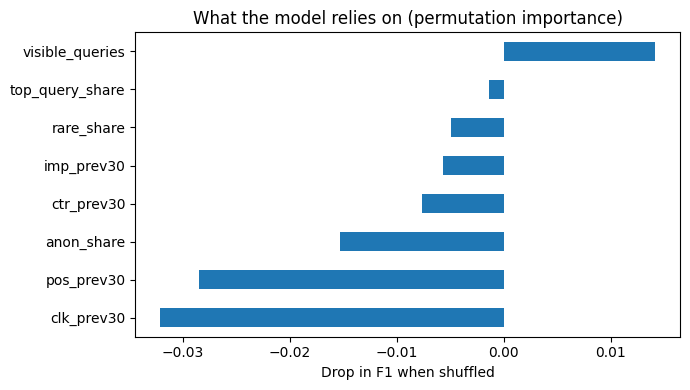

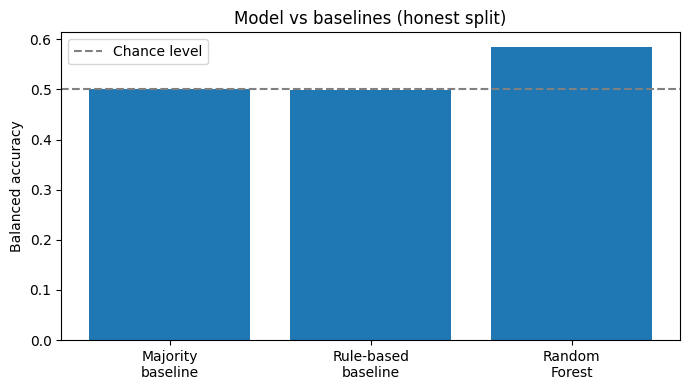

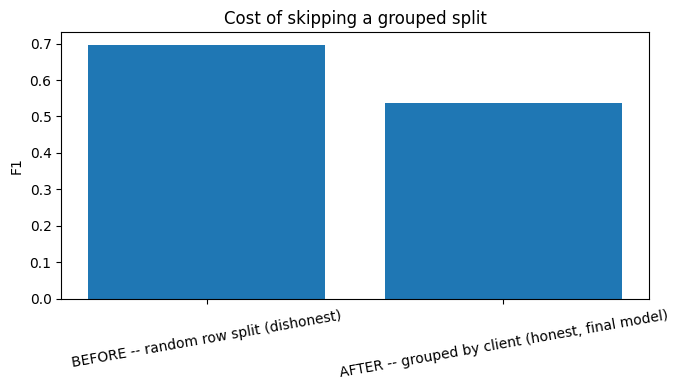

All artifacts saved to work/outputs/:
 - fig_honest_split_before_after.png
 - fig_model_vs_baseline.png
 - fig_permutation_importance.png
 - final_action_queue.csv
 - honest_split_before_after.csv
 - model_vs_baseline_final.csv


In [8]:
OUT_DIR = 'work/outputs'
os.makedirs(OUT_DIR, exist_ok=True)

final_comparison.to_csv(f'{OUT_DIR}/model_vs_baseline_final.csv', index=False)
before_after.to_csv(f'{OUT_DIR}/honest_split_before_after.csv', index=False)
queue.to_csv(f'{OUT_DIR}/final_action_queue.csv', index=False)

fig, ax = plt.subplots(figsize=(7, 4))
perm_series.plot(kind='barh', ax=ax)
ax.set_title('What the model relies on (permutation importance)')
ax.set_xlabel('Drop in F1 when shuffled')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/fig_permutation_importance.png', dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['Majority\nbaseline', 'Rule-based\nbaseline', 'Random\nForest'],
       final_comparison['balanced_accuracy'])
ax.axhline(0.5, color='grey', linestyle='--', label='Chance level')
ax.set_ylabel('Balanced accuracy'); ax.set_title('Model vs baselines (honest split)')
ax.legend()
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/fig_model_vs_baseline.png', dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(before_after['split'], before_after['f1'])
ax.set_ylabel('F1'); ax.set_title('Cost of skipping a grouped split')
plt.xticks(rotation=10)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/fig_honest_split_before_after.png', dpi=150); plt.show()

print('All artifacts saved to work/outputs/:')
for f in sorted(os.listdir(OUT_DIR)):
    print(' -', f)


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has all 9 sections — including the Abstract at the top and Acknowledgments & data credit (the https://flyrank.ai link) at the bottom.
- [ ] ML-12 done in this notebook's closing cells: 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


---
## ML-12 — Tell the Story

### 5-minute demo outline

1. **Question (30s):** “Which pages in a content portfolio are about to lose search visibility, and what should we do about each one first?”
2. **Method (1 min):** Built a Refresh/Decline classifier on ~102K real content-items from a 79M-row production search warehouse (FlyRank). Random Forest, validated with a client-grouped split so results reflect performance on *unseen* clients, not memorized ones.
3. **One chart (1.5 min):** Show `fig_model_vs_baseline.png` — walk through why raw F1 is misleading here (majority-class imbalance) and why balanced accuracy/ROC-AUC (0.586 / 0.631) are the honest comparison.
4. **One honest result (1 min):** The model beats both a dumb baseline and a real transparent hand-rule on unseen clients — but modestly. Show `fig_honest_split_before_after.png` to make the point that a naive random split would have overstated this by 15+ F1 points.
5. **One recommendation (1 min):** Show the top of the ranked queue — a real page-level example with its reason code and recommended action, tied directly back to FlyRank's own playbook language (refresh, CTR/snippet work, query-breadth expansion).

### Social post cut

> Built a decline-risk classifier on 79M rows of real search performance data (FlyRank's ML internship warehouse). The twist: a naive train/test split overstated performance by 15+ F1 points because it let the model “memorize” clients instead of learning transferable content signals. Fixing the split (grouping by client) gave an honest, if modest, result — ROC-AUC 0.63 on clients the model never saw. Full methodology, leakage checks, and a ranked action queue in the write-up. 👇

### Employer-facing summary (3 sentences)

I built and validated a content-decline classifier on a 79-million-row real production search dataset, using a client-grouped train/test split to guarantee the reported performance reflects generalization to unseen clients rather than memorization. The model (Random Forest, ROC-AUC 0.63) beat both a majority-class and a transparent rule-based baseline on the same honest split, and I quantified the exact cost (15+ F1 points) of skipping proper grouped validation. The end deliverable is a ranked, reason-coded action queue that turns model output into a concrete weekly triage list for a content team.
